<a href="https://colab.research.google.com/github/rafidhadizuhair/Laporan-Data-Mining-Rafid-Hadi-Zuhair_241011401361/blob/main/Pertemuan_7_dan_Tugas_Latihan_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# 1. Generate dataset yang tidak seimbang (Imbalanced)
# 90% data adalah Kelas 0, dan hanya 10% data adalah Kelas 1
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    weights=[0.9, 0.1],
    random_state=42
)

# 2. Split data
# 'stratify=y' sangat penting agar proporsi kelas di train & test tetap sama
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Train model menggunakan Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4. Hitung dan Tampilkan Metrik
print("=" * 50)
print("             EVALUASI MODEL CLASSIFICATION")
print("=" * 50)

print(f"Accuracy   : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision  : {precision_score(y_test, y_pred):.4f}")
print(f"Recall     : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score   : {f1_score(y_test, y_pred):.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("(Format: [[TN, FP], [FN, TP]])")

# 6. Classification Report (Lengkap)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Class 0', 'Class 1']))

# 7. Interpretasi Manual dari Confusion Matrix
tn, fp, fn, tp = cm.ravel()
print("\nInterpretasi Detil:")
print(f"True Negatives (Benar Prediksi 0)  : {tn}")
print(f"False Positives (Salah Prediksi 1) : {fp}")
print(f"False Negatives (Salah Prediksi 0) : {fn}")
print(f"True Positives (Benar Prediksi 1)  : {tp}")

             EVALUASI MODEL CLASSIFICATION
Accuracy   : 0.9533
Precision  : 0.8696
Recall     : 0.6452
F1-Score   : 0.7407

Confusion Matrix:
[[266   3]
 [ 11  20]]
(Format: [[TN, FP], [FN, TP]])

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.96      0.99      0.97       269
     Class 1       0.87      0.65      0.74        31

    accuracy                           0.95       300
   macro avg       0.91      0.82      0.86       300
weighted avg       0.95      0.95      0.95       300


Interpretasi Detil:
True Negatives (Benar Prediksi 0)  : 266
False Positives (Salah Prediksi 1) : 3
False Negatives (Salah Prediksi 0) : 11
True Positives (Benar Prediksi 1)  : 20


AUC Score: 0.9076


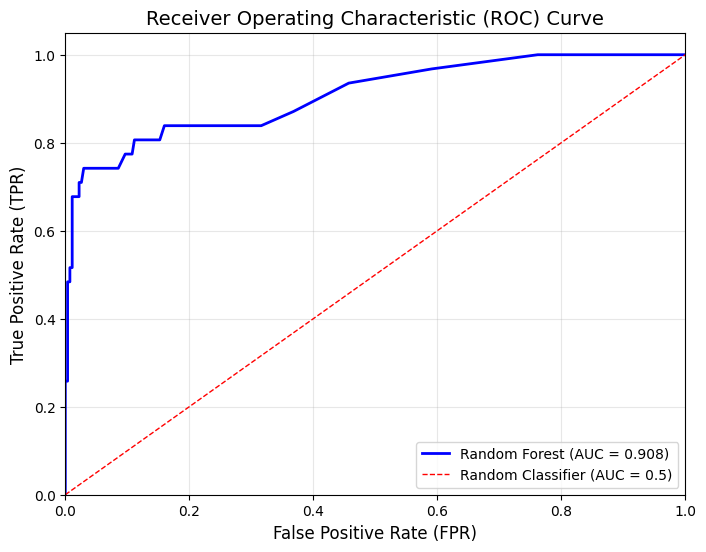


Analisis Threshold Optimal:
Optimal threshold (Youden's J) : 0.3300
TPR at optimal threshold       : 0.7419
FPR at optimal threshold       : 0.0297


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Dapatkan probabilitas untuk kelas positif (kelas 1)
# model.predict() memberikan label 0/1, sedangkan model.predict_proba() memberikan peluang 0.0-1.0
y_proba = model.predict_proba(X_test)[:, 1]

# 2. Hitung ROC curve (False Positive Rate & True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

print(f"AUC Score: {auc:.4f}")

# 3. Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 4. Mencari Threshold Optimal menggunakan Youden’s J Statistic
# J = TPR - FPR. Kita mencari selisih terbesar antara TPR dan FPR.
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\nAnalisis Threshold Optimal:")
print(f"Optimal threshold (Youden's J) : {optimal_threshold:.4f}")
print(f"TPR at optimal threshold       : {tpr[optimal_idx]:.4f}")
print(f"FPR at optimal threshold       : {fpr[optimal_idx]:.4f}")

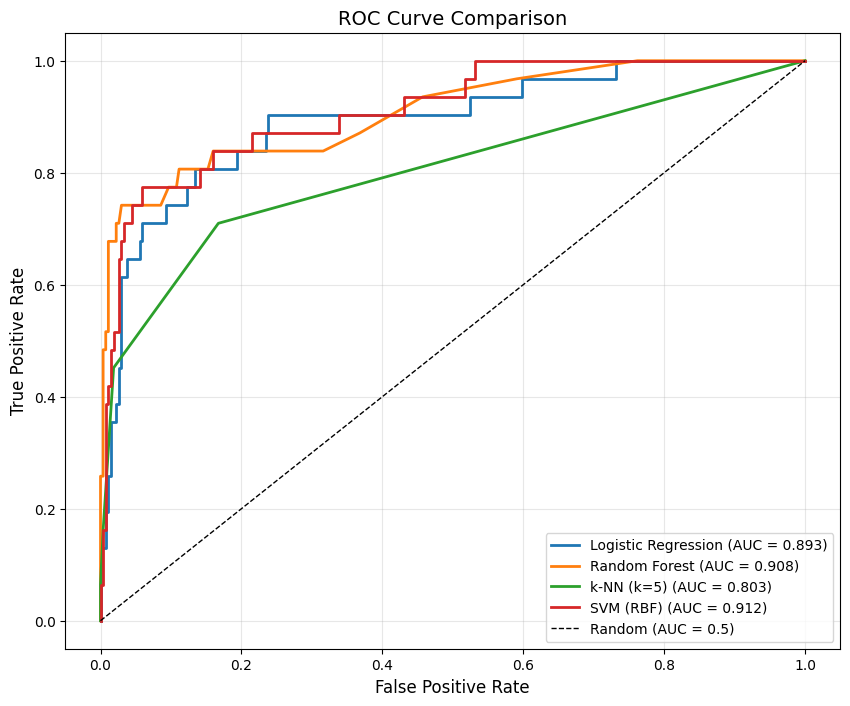

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Definisikan kumpulan model yang akan dibandingkan
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(probability=True, random_state=42)
}

# 2. Inisialisasi Plot
plt.figure(figsize=(10, 8))

# 3. Loop untuk Melatih, Menghitung, dan Plotting setiap model
for name, model in models.items():
    # Training model
    model.fit(X_train, y_train)

    # Mendapatkan probabilitas kelas positif
    y_proba = model.predict_proba(X_test)[:, 1]

    # Menghitung metrik ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    # Plotting kurva untuk model tersebut
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

# 4. Tambahkan garis referensi acak (Baseline)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')

# 5. Konfigurasi Label dan Judul
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [4]:
from sklearn.model_selection import (cross_val_score, KFold, StratifiedKFold, train_test_split)
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Inisialisasi Model
model = RandomForestClassifier(random_state=42)

# ============= 1. HOLD-OUT VALIDATION =============
# Melakukan pembagian data train/test sebanyak 10 kali dengan random state berbeda
print("=" * 50)
print("             HOLD-OUT VALIDATION (10 Repetitions)")
print("=" * 50)

scores_holdout = []
for i in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=i)
    model.fit(X_tr, y_tr)
    scores_holdout.append(model.score(X_te, y_te))

print(f"Mean Accuracy : {np.mean(scores_holdout):.4f}")
print(f"Std Deviation : {np.std(scores_holdout):.4f}")


# ============= 2. K-FOLD CROSS VALIDATION =============
print("\n" + "=" * 50)
print("           STANDARD K-FOLD CROSS VALIDATION")
print("=" * 50)

# K-Fold standar membagi data menjadi k bagian secara acak
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kfold = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

print(f"k-Fold (k=5) - Mean: {scores_kfold.mean():.4f} (+/- {scores_kfold.std():.4f})")


# ============= 3. STRATIFIED K-FOLD CV =============
print("\n" + "=" * 50)
print("              STRATIFIED K-FOLD CV")
print("=" * 50)

# Stratified K-Fold memastikan setiap lipatan (fold) memiliki proporsi kelas yang sama
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_strat = cross_val_score(model, X, y, cv=strat_kfold, scoring='accuracy')

print(f"Stratified k-Fold - Mean: {scores_strat.mean():.4f} (+/- {scores_strat.std():.4f})")


# ============= 4. PERBANDINGAN BERBAGAI NILAI K =============
print("\n" + "=" * 50)
print("        PERBANDINGAN AKURASI BERDASARKAN NILAI K")
print("=" * 50)

k_values = [3, 5, 7, 10]
for k in k_values:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    print(f"k={k:2}: Mean = {scores.mean():.4f}, Std = {scores.std():.4f}")

             HOLD-OUT VALIDATION (10 Repetitions)
Mean Accuracy : 0.9487
Std Deviation : 0.0093

           STANDARD K-FOLD CROSS VALIDATION
k-Fold (k=5) - Mean: 0.9540 (+/- 0.0080)

              STRATIFIED K-FOLD CV
Stratified k-Fold - Mean: 0.9530 (+/- 0.0117)

        PERBANDINGAN AKURASI BERDASARKAN NILAI K
k= 3: Mean = 0.9450, Std = 0.0135
k= 5: Mean = 0.9530, Std = 0.0117
k= 7: Mean = 0.9530, Std = 0.0148
k=10: Mean = 0.9490, Std = 0.0170


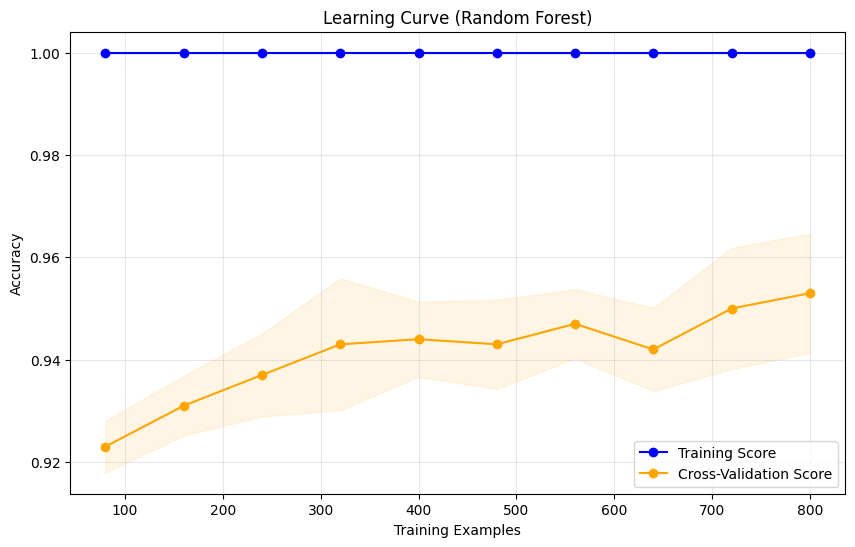

------------------------------
KESIMPULAN: MODEL GOOD FIT (Optimal)
------------------------------


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# 1. Menghitung Learning Curve
# Kita menguji performa model dari 10% data hingga 100% data pelatihan
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(random_state=42),
    X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)

# 2. Menghitung Rata-rata (Mean) dan Standar Deviasi (Std)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 3. Visualisasi Plot
plt.figure(figsize=(10, 6))

# Menampilkan area standar deviasi (ketidakpastian)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')

# Menampilkan garis utama
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-Validation Score')

plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve (Random Forest)')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

# 4. Interpretasi Otomatis
gap = train_mean[-1] - test_mean[-1]
print("-" * 30)
if gap > 0.1:
    print("KESIMPULAN: MODEL OVERFITTING")
    print("Solusi: Tambah data, kurangi kompleksitas model, atau gunakan regulerisasi.")
elif train_mean[-1] < 0.7:
    print("KESIMPULAN: MODEL UNDERFITTING")
    print("Solusi: Gunakan model yang lebih kompleks atau tambahkan fitur baru.")
else:
    print("KESIMPULAN: MODEL GOOD FIT (Optimal)")
print("-" * 30)

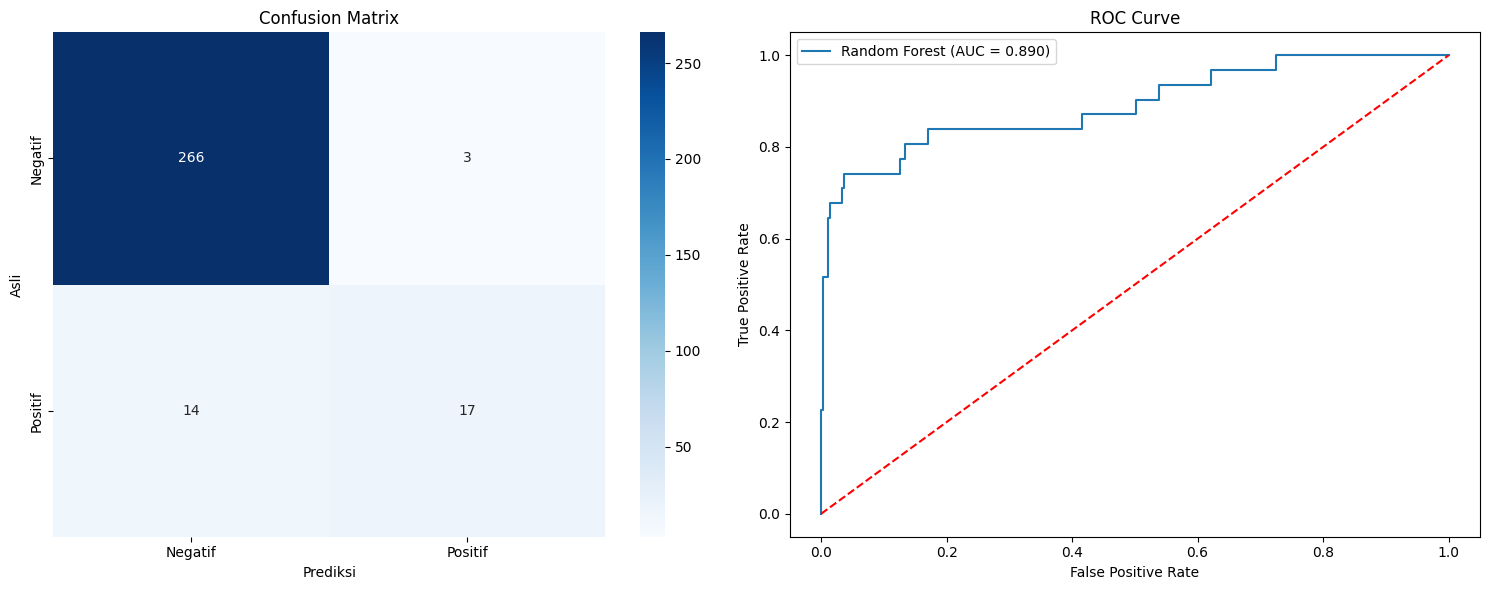

HASIL EVALUASI MODEL
Accuracy  : 0.9433
Precision : 0.8500
Recall    : 0.5484
F1-Score  : 0.6667

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       269
           1       0.85      0.55      0.67        31

    accuracy                           0.94       300
   macro avg       0.90      0.77      0.82       300
weighted avg       0.94      0.94      0.94       300


Stratified 5-Fold CV Accuracy: 0.9490 (+/- 0.0107)


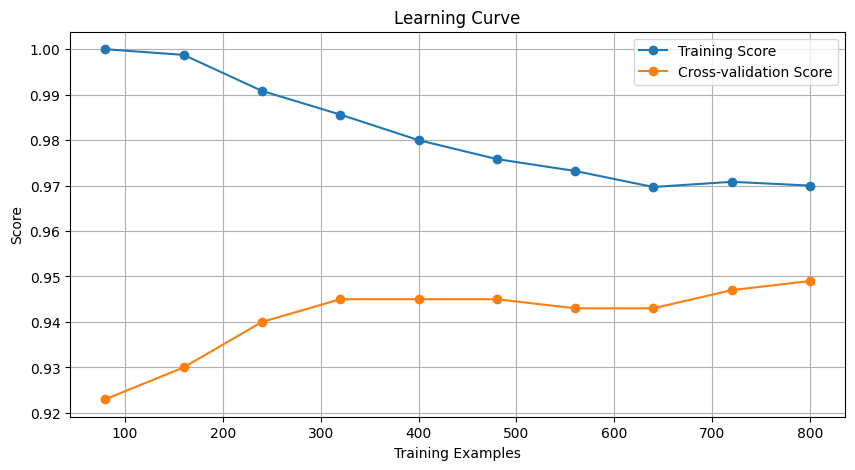

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score)

# 1. Persiapan Dataset (Imbalanced)
X, y = make_classification(n_samples=1000, n_features=20, weights=[0.9, 0.1], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2. Training Model
model = RandomForestClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# --- VISUALISASI ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# A. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Asli')

# B. Visualisasi ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Output Metrik Evaluasi
print("="*50)
print("HASIL EVALUASI MODEL")
print("="*50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 4. Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=skf)
print(f"\nStratified 5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 5. Visualisasi Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=skf, train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Cross-validation Score')
plt.title('Learning Curve')
plt.xlabel('Training Examples')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

--- Hasil Stratified 10-Fold CV ---
                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression    0.8011     0.7837  0.7138  0.7438   0.8562
1        Random Forest    0.8123     0.8464  0.6621  0.7395   0.8679
2            SVM (RBF)    0.8136     0.8345  0.6828  0.7462   0.8537


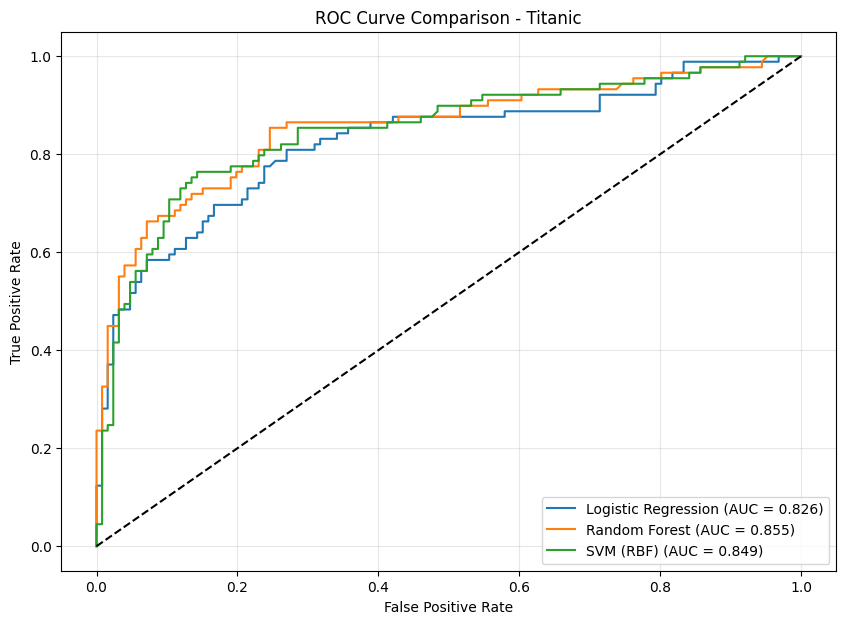

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, make_scorer, accuracy_score, precision_score, recall_score, f1_score

# 1. Load & Preprocessing Data
df = sns.load_dataset('titanic')
# Memilih fitur yang relevan & menghapus baris kosong
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].dropna()

# Encoding & Scaling
df['sex'] = LabelEncoder().fit_transform(df['sex'])
X = df.drop('survived', axis=1)
y = df['survived']
X_scaled = StandardScaler().fit_transform(X)

# 2. Inisialisasi Model
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'SVM (RBF)': SVC(probability=True, random_state=42)
}

# 3. Evaluasi Fair dengan Stratified 10-Fold CV
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results = []

print("--- Hasil Stratified 10-Fold CV ---")
for name, model in models.items():
    cv_results = cross_validate(model, X_scaled, y, cv=skf, scoring=metrics)
    results.append({
        'Model': name,
        'Accuracy': cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall': cv_results['test_recall'].mean(),
        'F1': cv_results['test_f1'].mean(),
        'ROC-AUC': cv_results['test_roc_auc'].mean()
    })

results_df = pd.DataFrame(results)
print(results_df.round(4))

# 4. Plot ROC Curve Multi-Model
plt.figure(figsize=(10, 7))
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Titanic')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()